In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from src.commons import data_loader

# 1. Optimize JupyterLab display aesthetics

In [2]:
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)

polars.config.Config

# 2. Open an un-materialized high-performance file stream pointer

In [3]:
df = data_loader.read_csv("scada_dms.csv")

# 3. Data Profiling

In [4]:
# 3.1. SCADA DMS Schema
print("--- Scada DMS Schema Preview ---")
print(df.schema)

--- Scada DMS Schema Preview ---
Schema([('System ID', String), ('Provider ID', String), ('Function', String), ('Control Center', String)])


In [5]:
# 3,2. SCADA DMS -  Data Shape & Describe Preview
print("--- Scada dms -  Shape and Describe Preview ---")
print(df.glimpse())

--- Scada dms -  Shape and Describe Preview ---
Rows: 10
Columns: 4
$ System ID      <str> 'SCD-001', 'SCD-002', 'SCD-003', 'SCD-004', 'SCD-005', 'SCD-006', 'SCD-007', 'SCD-008', 'SCD-009', 'SCD-010'
$ Provider ID    <str> 'UP-002', 'UP-003', 'UP-004', 'UP-003', 'UP-003', 'UP-005', 'UP-001', 'UP-003', 'UP-003', 'UP-003'
$ Function       <str> 'SCADA+DMS', 'SCADA', 'SCADA+DMS', 'SCADA', 'DMS', 'DMS', 'SCADA+DMS', 'DMS', 'SCADA', 'SCADA'
$ Control Center <str> 'Control Center 1', 'Control Center 2', 'Control Center 3', 'Control Center 4', 'Control Center 5', 'Control Center 6', 'Control Center 7', 'Control Center 8', 'Control Center 9', 'Control Center 10'

None


# 4. Count missing values in parallel across millions of records

In [6]:
# Create a comprehensive audit summary
total_rows = df.height
null_counts = df.select(pl.all().is_null().sum())
null_pcts = df.select((pl.all().is_null().sum() / total_rows * 100).round(2))

# Reshape them vertically using unpivot
counts_vertical = null_counts.unpivot(variable_name="Column", value_name="Null Count")
pcts_vertical = null_pcts.unpivot(variable_name="Column", value_name="Null Percentage (%)")

# Join them together by the Column name
audit_df = counts_vertical.join(pcts_vertical, on="Column").sort("Null Count", descending=True)

print(audit_df)

shape: (4, 3)
┌────────────────┬────────────┬─────────────────────┐
│ Column         ┆ Null Count ┆ Null Percentage (%) │
│ ---            ┆ ---        ┆ ---                 │
│ str            ┆ u32        ┆ f64                 │
╞════════════════╪════════════╪═════════════════════╡
│ System ID      ┆ 0          ┆ 0.0000              │
│ Provider ID    ┆ 0          ┆ 0.0000              │
│ Function       ┆ 0          ┆ 0.0000              │
│ Control Center ┆ 0          ┆ 0.0000              │
└────────────────┴────────────┴─────────────────────┘


# 5 Plotting chart about metrics generated from the exploration.

In [7]:
# 5.1.. Calculate the metrics
total_rows = df.height

# Count actual Polars 'null' values across all columns
total_nulls = df.select(pl.all().is_null().sum()).sum_horizontal().item()


# Count empty strings ("") which often represent missing text data
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
if string_cols:
    total_empty_strings = df.select(pl.col(string_cols).eq("").sum()).sum_horizontal().item()
else:
    total_empty_strings = 0

In [8]:
# 5.2.. Setup data for plotting
metrics = ['Total Rows', 'Null Values', 'Missing (Empty Strings)']
counts = [total_rows, total_nulls, total_empty_strings]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

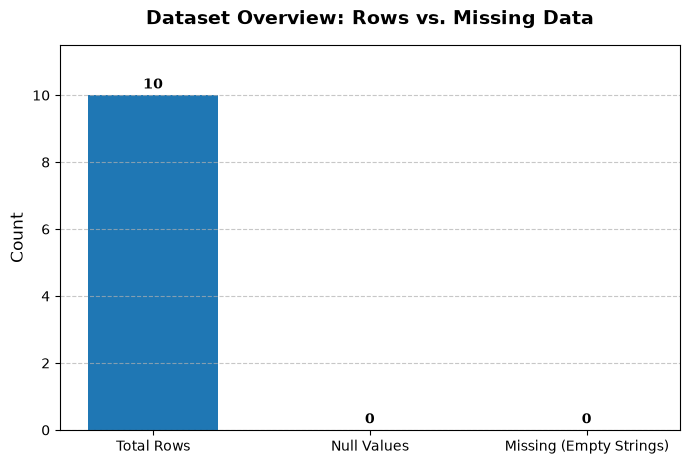

In [9]:
# 5.3. Generate the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, counts, color=colors, width=0.6)

# Add exact value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.01), 
             f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Overview: Rows vs. Missing Data', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to give space for labels
plt.ylim(0, max(counts) * 1.15)

plt.show()